# Evaluación out-of-domain: zonas fuera de Chaco-Santiago

Evalúa `models/full_model` sobre 7 zonas geográficamente disjuntas del área
de entrenamiento (Chaco/Santiago del Estero/frontera agrícola), cada una
dominada por una modalidad de uso de suelo distinta. Las zonas se
construyeron con `scripts/build_eval_zones.py` (ver ese script para el
detalle de los bbox y la verificación de disjunción geográfica).

Corrige dos problemas de evaluación documentados en
`notebooks/test_2.ipynb`:
- `collect_predictions` se corre sin `max_batches` (dataset completo, no
  las primeras N filas).
- `compute_metrics` fija `labels=` a las 11 clases del vocabulario
  (excepto `[UNK]`), así el macro F1 es comparable entre zonas con
  distinta composición de clases.

Baseline in-domain honesto (test set actual, filas sin leakage,
`test_2.ipynb`): **Accuracy 0.9929 / Macro F1 0.9005**.

In [1]:
import dataclasses
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from land2vec.dataset import load_data
from land2vec.tokenizer import Tokenizer
from land2vec.utils import load_config, load_model, collect_predictions, compute_metrics

DATA_DIR = Path("data")

In [2]:
target_folder = Path("models/full_model")
config = load_config(target_folder)
config = dataclasses.replace(config, device="cuda" if torch.cuda.is_available() else "cpu")
model = load_model(config, target_folder)
print(f"device={config.device}  params={sum(p.numel() for p in model.parameters()):,}")

device=cpu  params=795,520


## Zonas de evaluación

In [3]:
ZONES = [
    "puna_noa",
    "patagonia_estepa",
    "periurbano_cordoba",
    "ibera",
    "delta_parana",
    "pampa_nucleo",
    "misiones_selva",
]

# Mismos pesos de clase (inverso de frecuencia en train) que test_1.ipynb / test_2.ipynb,
# solo se usan para la loss ponderada que reporta collect_predictions -- no afectan
# accuracy/macro-F1, que se calculan sobre argmax(logits) vs. target real.
weights = torch.tensor([0.0000e+00, 1.5647e-03, 1.2274e-03, 1.3506e-02, 7.2318e-03, 3.4001e-02,
        2.0295e-03, 4.2922e-02, 4.9384e+00, 2.0722e-02, 4.9384e+00]).to(config.device)

VALID_LABELS = [i for i in Tokenizer.VOCAB.values() if i != Tokenizer.VOCAB["[UNK]"]]
LABEL_NAMES = [Tokenizer.REVERSE_VOCAB[i] for i in VALID_LABELS]

In [4]:
@torch.no_grad()
def accuracy_by_position(model, loader, device):
    "Accuracy promedio por posición dentro de la secuencia (ver test_1.ipynb)."
    model.eval()
    acc_sum, batches = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(dim=-1)
        acc_sum += (preds == y).float().mean(dim=0)
        batches += 1
    return (acc_sum / batches).cpu().numpy()

## Evaluación por zona\n\nCorre sobre el dataset completo de cada zona (sin truncar batches).

In [5]:
results = {}

for zone in ZONES:
    t0 = time.time()
    seqs_path = DATA_DIR / f"id_seqs_text_2000_2022_{zone}.zip"
    dataset = load_data(file_path=seqs_path)
    loader = DataLoader(dataset, shuffle=False, batch_size=1024, num_workers=0)

    preds, targets, avg_loss = collect_predictions(model, loader, config.device, weights, max_batches=None)
    metrics = compute_metrics(targets, preds, labels=VALID_LABELS)
    pos_acc = accuracy_by_position(model, loader, config.device)
    cm = confusion_matrix(targets, preds, labels=VALID_LABELS, normalize="true")

    results[zone] = {
        "n_pixels": len(dataset),
        "n_tokens": len(targets),
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "avg_loss": avg_loss,
        "pos_acc": pos_acc,
        "confusion_matrix": cm,
        "targets": targets,
        "preds": preds,
    }
    acc, f1 = metrics["accuracy"], metrics["macro_f1"]
    print(f"[{zone}] n_pixels={len(dataset):,} accuracy={acc:.4f} macro_f1={f1:.4f} ({time.time()-t0:.0f}s)")

  0%|          | 0/388800 [00:00<?, ?it/s]

  1%|▏         | 5138/388800 [00:00<00:21, 17797.37it/s]

  3%|▎         | 11607/388800 [00:00<00:11, 33318.55it/s]

  4%|▍         | 16735/388800 [00:00<00:09, 39083.03it/s]

  6%|▌         | 24088/388800 [00:00<00:07, 49911.15it/s]

...

 95%|█████████▍| 368873/388800 [00:05<00:00, 79464.89it/s]

 97%|█████████▋| 376896/388800 [00:05<00:00, 72692.79it/s]

 99%|█████████▉| 384588/388800 [00:05<00:00, 73840.58it/s]

100%|██████████| 388800/388800 [00:05<00:00, 69288.67it/s]

[misiones_selva] n_pixels=388,800 accuracy=0.9982 macro_f1=0.6947 (165s)


## Resumen: pooled vs. por zona

In [6]:
all_targets = np.concatenate([r["targets"] for r in results.values()])
all_preds = np.concatenate([r["preds"] for r in results.values()])
pooled_metrics = compute_metrics(all_targets, all_preds, labels=VALID_LABELS)

summary = pd.DataFrame([
    {"zone": zone, "n_pixels": r["n_pixels"], "accuracy": r["accuracy"], "macro_f1": r["macro_f1"]}
    for zone, r in results.items()
] + [{"zone": "POOLED (7 zonas)", "n_pixels": sum(r["n_pixels"] for r in results.values()),
      "accuracy": pooled_metrics["accuracy"], "macro_f1": pooled_metrics["macro_f1"]}])

summary["macro_f1_gap_vs_indomain"] = summary["macro_f1"] - 0.9005
summary["accuracy_gap_vs_indomain"] = summary["accuracy"] - 0.9929
summary

,zone,n_pixels,accuracy,macro_f1,macro_f1_gap_vs_indomain,accuracy_gap_vs_indomain
0,puna_noa,388800,0.604197,0.468244,-0.432256,-0.388703
1,patagonia_estepa,1555200,0.995725,0.650213,-0.250287,0.002825
2,periurbano_cordoba,20736,0.995042,0.796868,-0.103632,0.002142
3,ibera,291600,0.995070,0.794637,-0.105863,0.002170
4,delta_parana,181440,0.997084,0.810115,-0.090385,0.004184
5,pampa_nucleo,518400,0.999336,0.792023,-0.108477,0.006436
6,misiones_selva,388800,0.998176,0.694689,-0.205811,0.005276
7,POOLED (7 zonas),3344976,0.951073,0.750672,-0.149828,-0.041827


**Baseline in-domain (honesto, sin leakage, `test_2.ipynb`)**: Accuracy 0.9929 / Macro F1 0.9005.

## Matrices de confusión por zona

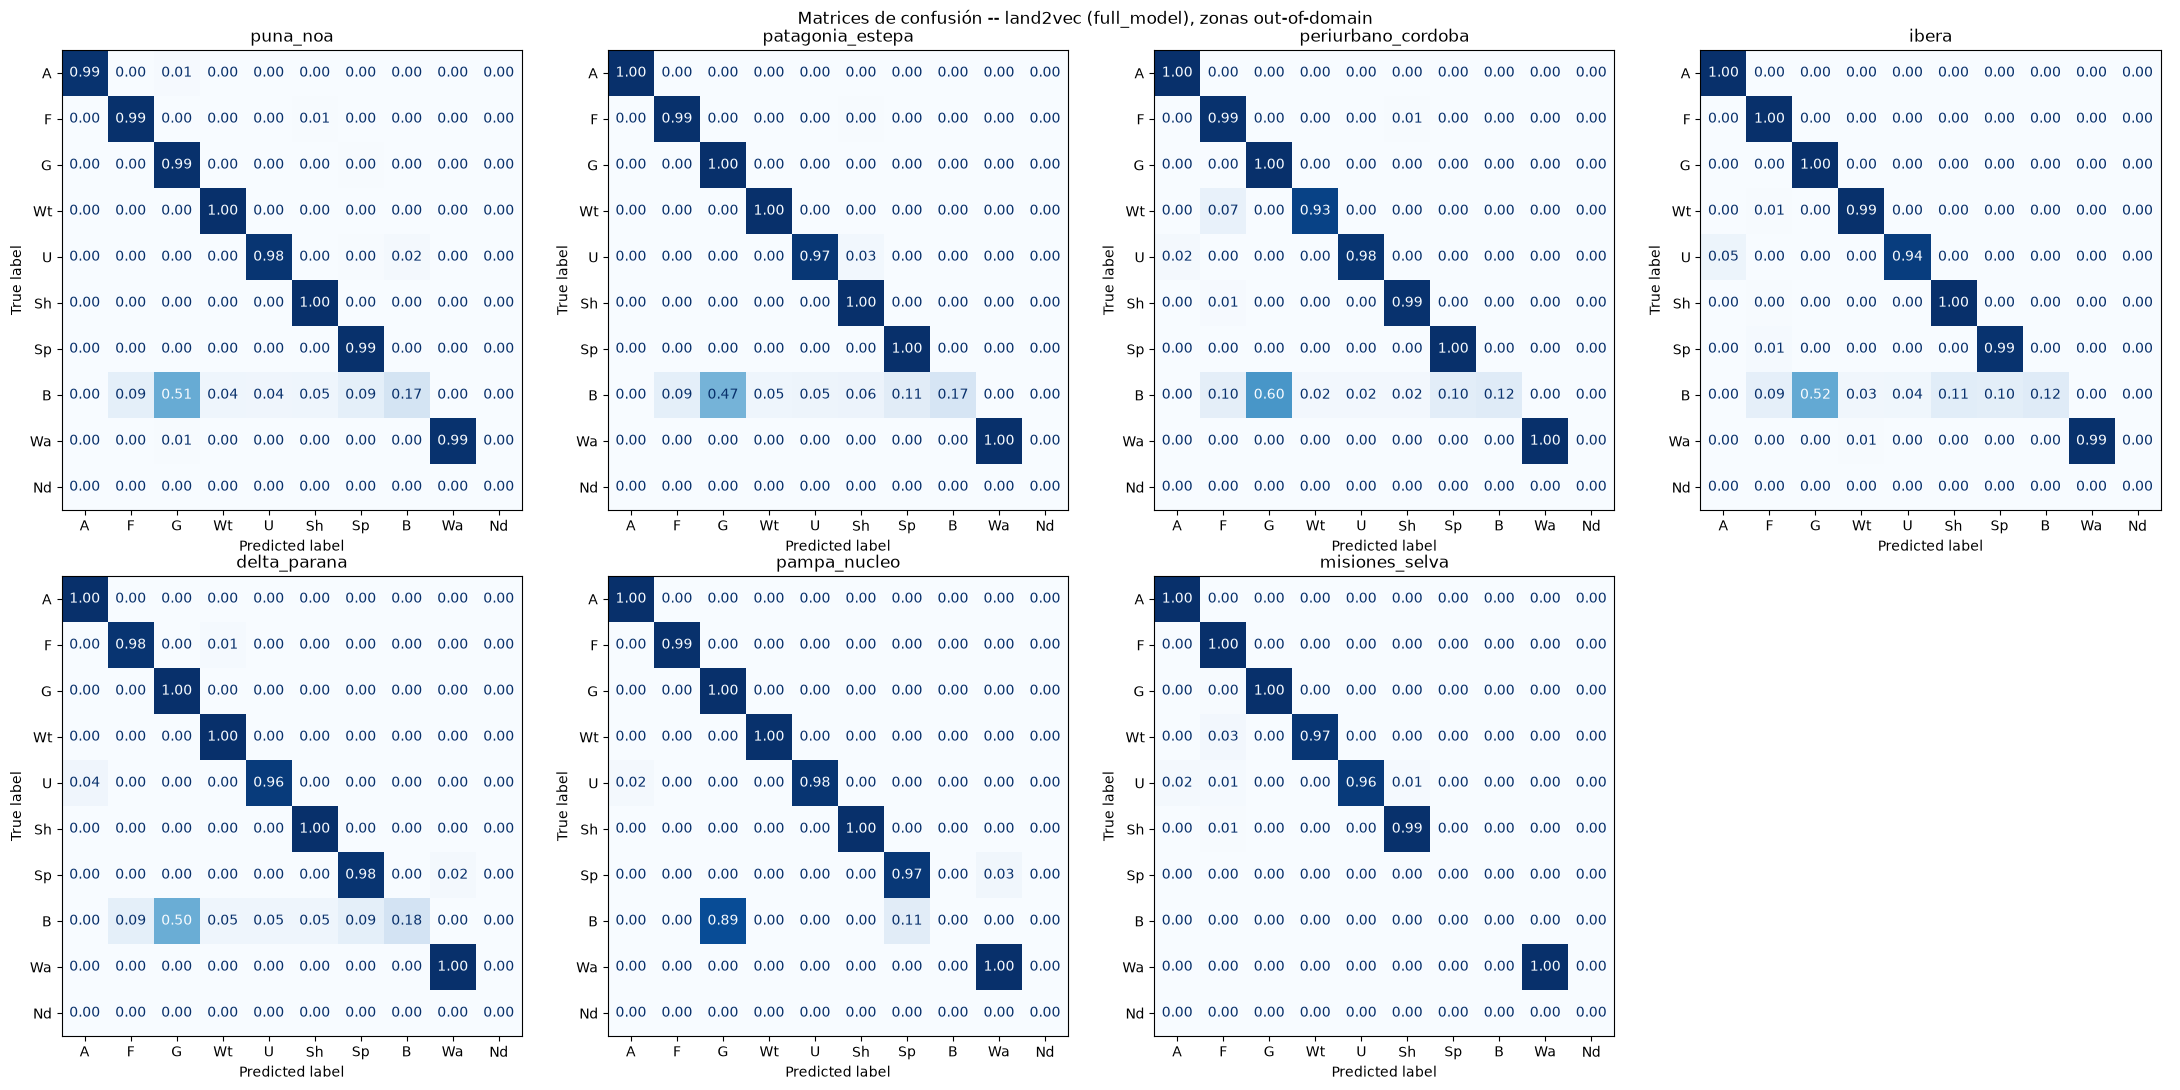

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
for ax, zone in zip(axes.flat, ZONES):
    disp = ConfusionMatrixDisplay(confusion_matrix=results[zone]["confusion_matrix"], display_labels=LABEL_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(zone)
    ax.grid(False)
axes.flat[-1].axis("off")
fig.suptitle("Matrices de confusión -- land2vec (full_model), zonas out-of-domain")
fig.tight_layout()
plt.show()

## Accuracy por posición de secuencia

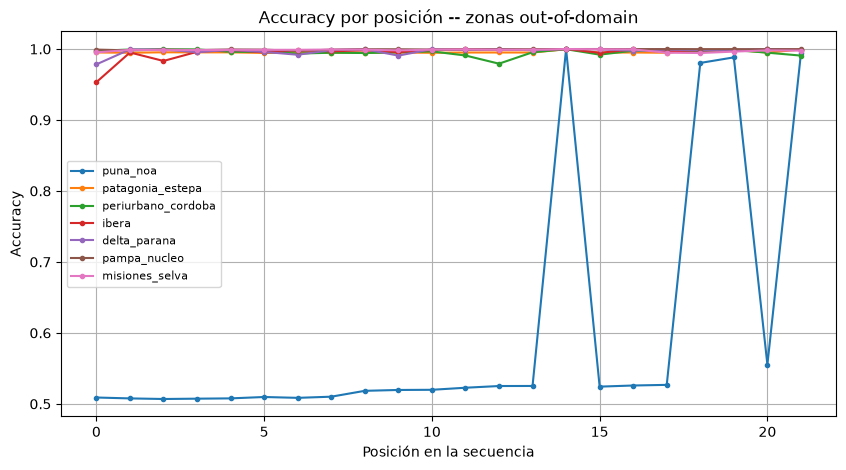

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for zone in ZONES:
    ax.plot(results[zone]["pos_acc"], marker="o", markersize=3, label=zone)
ax.set_xlabel("Posición en la secuencia")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por posición -- zonas out-of-domain")
ax.legend(fontsize=8)
ax.grid(True)
plt.show()

## Conclusiones

Resultados reales (`models/full_model`, CPU, dataset completo por zona, sin
leakage posible -- las 7 zonas son bbox-disjuntas de train y del test set
actual):

| Zona | n_pixels | Accuracy | Macro F1 | Gap Macro F1 vs. in-domain (0.9005) |
|---|---:|---:|---:|---:|
| `puna_noa` (B=47.5%, Sp=36.9%) | 388,800 | 0.6042 | 0.4682 | **-0.432** |
| `patagonia_estepa` (Sp=54.0%, Sh=44.0%) | 1,555,200 | 0.9957 | 0.6502 | -0.250 |
| `misiones_selva` (F=70.9%, A=23.9%) | 388,800 | 0.9982 | 0.6947 | -0.206 |
| `pampa_nucleo` (A=89.3%) | 518,400 | 0.9993 | 0.7920 | -0.108 |
| `ibera` (Wt=51.4%, F=22.6%) | 291,600 | 0.9951 | 0.7946 | -0.106 |
| `periurbano_cordoba` (A=69.0%, U=14.5%) | 20,736 | 0.9950 | 0.7969 | -0.104 |
| `delta_parana` (A=44.0%, Wt=34.7%, G=13.5%) | 181,440 | 0.9971 | 0.8101 | -0.090 |
| **POOLED (7 zonas)** | **3,344,976** | **0.9511** | **0.7507** | **-0.150** |

**1. El accuracy no detecta la falla de generalización, el macro F1 sí.**
En 6 de las 7 zonas el accuracy se mantiene igual o mejor que el baseline
in-domain (0.9929) -- porque la clase mayoritaria en casi cualquier parcela
es "no cambio interanual", trivial de acertar. El macro F1 cae entre 9 y 43
puntos porcentuales en *todas* las zonas: el modelo memorizó bien la
dinámica dominante de Chaco-Santiago (F/A/Sh) pero no generaliza a otras
transiciones de uso de suelo.

**2. `puna_noa` es el fracaso más claro**: es la única zona donde también
colapsa el accuracy (0.60). Es la zona con más peso de `B` y `Sp`, las dos
clases casi ausentes en entrenamiento (`B` es 0% en train). El modelo no
tiene con qué predecir transiciones hacia/desde esas clases.

**3. Incluso con las mismas clases dominantes, hay brecha real.**
`misiones_selva` tiene la misma mezcla F/A que domina el train (F=70.9%,
A=23.9%), pero el macro F1 igual cae a 0.69 -- la dinámica temporal de la
selva misionera (otro bioma, otra deforestación/reforestación) no es la
misma que la de la frontera agrícola chaqueña, aunque el vocabulario de
clases coincida.

**4. Zonas con mezclas más parecidas a train (`delta_parana`, `ibera`,
`periurbano_cordoba`, `pampa_nucleo`) degradan menos** (macro F1 ~0.79-0.81)
pero ninguna llega al 0.9005 in-domain -- confirma que ni siquiera la
región geográfica más "amigable" logra igualar el desempeño reportado
originalmente, que estaba inflado por el área de estudio compartida con
train (ver `notebooks/test_2.ipynb`).

**Recomendación**: para que `land2vec` generalice a modalidades de uso de
suelo poco representadas (`B`, `Sp`, `U`, `Wt`, `G`, `Wa`), el dataset de
entrenamiento necesita datos de zonas con esas clases, no solo más datos de
Chaco-Santiago.